# FraudGuard - Exploratory Data Analysis
This notebook explores transaction data for fraud detection.

## 1. Environment Setup — Installing Required Libraries

**What this does:**  
Installs the core Python data science libraries: `pandas`, `numpy`, `matplotlib`, and `seaborn`.

**Why it's relevant:**  
These libraries form the backbone of any EDA workflow:
- **pandas** — provides DataFrame structures for tabular data manipulation, filtering, grouping, and statistical summaries.
- **numpy** — enables fast numerical operations on arrays, which underlies most pandas and scikit-learn operations.
- **matplotlib** — the foundational plotting library; all other Python plotting libraries build on it.
- **seaborn** — a high-level statistical visualization library built on matplotlib, offering aesthetically pleasing defaults and built-in support for statistical plots (boxplots, heatmaps, countplots, etc.).

**How it's done:**  
The `!pip install` syntax runs shell commands directly from the notebook cell, ensuring the environment has the required packages before any analysis begins.

In [11]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   ----------------------- ---------------- 5.5/9.5 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 26.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ------------ --------------------------- 11.3/36.6 MB 51.7 MB/s eta 0:00:01
   ----------------------- ---------------- 21.2/36.6 MB 49.6 MB/s eta 0:00:01
   --------------------------------- ------ 30.9/36.6 MB 48.7 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 44.7 MB/s eta 0:00:00


## 2. Library Imports and Global Configuration

**What this does:**  
Imports all four libraries into the notebook's namespace and applies a consistent visual theme for all subsequent plots.

**Why it's relevant:**  
- Explicit imports make the notebook self-contained and reproducible — anyone running it knows exactly which libraries are used.
- `sns.set_style('whitegrid')` applies a clean, publication-ready style to all seaborn/matplotlib plots, ensuring consistent aesthetics.
- `%matplotlib inline` is a Jupyter magic command that renders plots directly below the code cell that generates them, keeping the visual output tied to the code that produced it.

**How it's done:**  
Standard Python `import` statements bring the libraries into scope. The `%matplotlib inline` magic is specific to Jupyter/IPython environments and configures the backend to display static images inline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

## 3. Data Loading — Reading the Transaction Dataset

**What this does:**  
Changes the working directory to the project root, verifies the `data/raw/` directory exists, and loads the `train_transaction.csv` file into a pandas DataFrame.

**Why it's relevant:**  
- The notebook runs from the `notebooks/` subdirectory, but the data lives in `data/raw/` relative to the project root. Changing the directory (`os.chdir('..')`) ensures the relative path `data/raw/train_transaction.csv` resolves correctly.
- Printing the current directory and listing files provides immediate feedback that the environment is set up as expected — a simple sanity check before the actual load.
- Loading the data into a DataFrame (`df`) is the foundational step; every subsequent analysis in this notebook operates on this object.

**How it's done:**  
`os.chdir('..')` navigates up one directory level. `os.path.exists()` checks for the data directory. `pd.read_csv()` reads the CSV file into a DataFrame, and `.head()` displays the first 5 rows to confirm the data loaded correctly and to give a quick preview of column names and data types.

In [3]:
import os

# Try multiple directory approaches to find the data
possible_paths = [
    'data/raw/train_transaction.csv',
    '../data/raw/train_transaction.csv',
    '../../data/raw/train_transaction.csv',
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        print(f"Found data at: {path}")
        break

if data_path is None:
    print("Current working directory:", os.getcwd())
    print("Could not find train_transaction.csv in expected locations.")
    print("Please ensure the file is in the data/raw/ directory relative to this notebook.")
else:
    df = pd.read_csv(data_path)
    print(f"Loaded {len(df)} rows")
    df.head()

Found data at: ../data/raw/train_transaction.csv
Loaded 590540 rows


## 4. Initial Dataset Exploration — Shape, Columns, Missing Values, and Target Distribution

**What this does:**  
Provides a comprehensive first look at the dataset: its dimensions (rows × columns), column names, a preview of the first 5 rows, missing value counts, fraud rate, and a statistical summary of numeric features.

**Why it's relevant:**  
- **Shape** — tells us how many transactions and features we're working with, which informs memory requirements and model complexity.
- **Column listing** — reveals the feature naming convention (e.g., `V*`, `C*`, `D*` anonymized features, `TransactionAmt`, `TransactionDT`, categorical columns like `ProductCD`, `card4`, etc.).
- **Missing values** — fraud datasets often have extensive missing data (especially in anonymized V features). Identifying which columns have high null rates early guides imputation or drop decisions.
- **Fraud rate** — critical for understanding class imbalance. A very low fraud rate (e.g., <5%) means we'll need techniques like class weighting, oversampling (SMOTE), or undersampling during modeling.
- **Numeric summary** — `.describe()` gives min, max, mean, quartiles for every numeric column, helping spot outliers, scale differences, and distribution shapes.

**How it's done:**  
`df.shape` returns (rows, cols). `df.columns.tolist()` lists all column names. `df.isnull().sum()` counts missing values per column, sorted descending to highlight the worst offenders first. `df['is_fraud'].mean() * 100` computes the fraud percentage. `df.describe(include=[np.number]).T` transposes the numeric summary for easier reading.

In [4]:
# Quick summary of what the dataset contains

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

# Basic dataset summary
print("\nMissing values (top 20):")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(20))

# Fraud target summary if present
if 'is_fraud' in df.columns:
    fraud_rate = df['is_fraud'].mean() * 100
    print(f"\nFraud rate: {fraud_rate:.2f}%")
    print("\nFraud label counts:")
    print(df['is_fraud'].value_counts())

# Numeric overview
print("\nNumeric feature summary:")
display(df.describe(include=[np.number]).T)

Shape: (590540, 394)

Columns:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77',

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Missing values (top 20):
dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V149     508595
V141     508595
V146     508595
V154     508595
V162     508595
V142     508595
V158     508595
V161     508595
V157     508595
V138     508595
V139     508595
dtype: int64

Numeric feature summary:


,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
V335,82351.0,5.916455e+01,3.876295e+02,0.000,0.000,0.000,0.00,5.512500e+04
V336,82351.0,2.853090e+01,2.745769e+02,0.000,0.000,0.000,0.00,5.512500e+04
V337,82351.0,5.535242e+01,6.684868e+02,0.000,0.000,0.000,0.00,1.040600e+05
V338,82351.0,1.511605e+02,1.095034e+03,0.000,0.000,0.000,0.00,1.040600e+05


## 5. Detailed Data Types and Statistical Summary

**What this does:**  
`df.info()` prints a concise summary of the DataFrame including column data types (dtypes), non-null counts, and memory usage. `df.describe()` provides a statistical summary of all numeric columns.

**Why it's relevant:**  
- **Data types** — confirms which columns are numeric (`float64`, `int64`) vs. categorical (`object`). This is essential because different preprocessing steps apply to different types (e.g., scaling for numeric, encoding for categorical).
- **Non-null counts** — `df.info()` shows exactly how many non-null values each column has, giving a more precise picture of missingness than the earlier summary.
- **Memory usage** — important for large datasets; if memory is a concern, we may need to downcast dtypes or load in chunks.
- **Statistical summary** — `.describe()` provides count, mean, std, min, 25%, 50%, 75%, max for each numeric column, which helps identify outliers (e.g., `TransactionAmt` max being orders of magnitude above the 75th percentile) and understand feature scales.

**How it's done:**  
`df.info()` is called with default parameters. `df.describe()` by default only includes numeric columns. Both are built-in pandas methods that require no additional configuration.

In [5]:
# Basic info
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


## 6. Missing Value Analysis — Per-Column Null Counts

**What this does:**  
Computes and displays the total number of missing (null) values for every column in the dataset.

**Why it's relevant:**  
- This is a more granular view than the earlier top-20 missing values. Seeing the full list helps identify patterns: some columns may have 0 missing values (complete), while others may have near-total missingness (>90%).
- Columns with very high null rates are candidates for removal rather than imputation, because imputing 90%+ of values would introduce more noise than signal.
- Columns with moderate missingness (e.g., 10-50%) may benefit from imputation strategies (mean/median for numeric, mode for categorical, or model-based imputation).
- Understanding the missing data mechanism (MCAR, MAR, MNAR) is important for choosing the right handling strategy.

**How it's done:**  
`df.isnull()` creates a boolean mask of the same shape as `df` (True where missing). `.sum()` sums the True values column-wise, returning a Series with the total null count per column.

In [6]:
# Check for missing values
df.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
V335              508189
V336              508189
V337              508189
V338              508189
V339              508189
Length: 394, dtype: int64

## 7. Target Variable Distribution — Fraud vs. Legitimate Transactions

**What this does:**  
Creates a bar plot showing the count of fraudulent (`isFraud=1`) vs. legitimate (`isFraud=0`) transactions.

**Why it's relevant:**  
- This is the single most important visualization in any fraud detection EDA. It reveals the **class imbalance** — typically fraud cases are a tiny fraction (often <1-5%) of all transactions.
- Severe class imbalance has major implications for model selection and evaluation:
  - Accuracy becomes a misleading metric (a model that predicts "not fraud" for every transaction would be >95% accurate but completely useless).
  - We need metrics like **Precision, Recall, F1-score, and AUC-PR** instead of accuracy.
  - We may need to use class weights, oversampling (SMOTE), undersampling, or anomaly detection approaches.
- The countplot also confirms the target column is properly binary (0/1) with no unexpected values.

**How it's done:**  
`sns.countplot(x='isFraud', data=df)` creates a bar chart where the x-axis has two categories (0 and 1) and the y-axis shows the count of each. `plt.title()` adds a descriptive title, and `plt.show()` renders the plot.

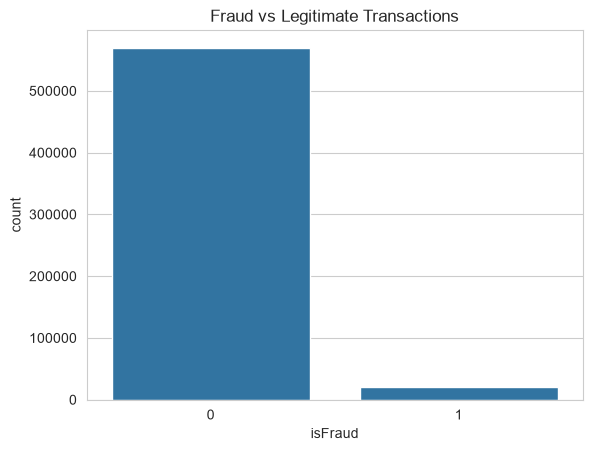

In [7]:
# Target distribution
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Legitimate Transactions')
plt.show()

## 8. Transaction Amount Analysis — Distribution and Fraud Comparison

**What this does:**  
Creates two side-by-side plots: (1) a histogram of all transaction amounts, and (2) a boxplot comparing transaction amounts for fraudulent vs. legitimate transactions.

**Why it's relevant:**  
- **Transaction amount** is often one of the most predictive features in fraud detection. Fraudsters may target specific amount ranges (e.g., just below reporting thresholds, or very high-value items).
- The **histogram** reveals the overall distribution shape — typically right-skewed (many small transactions, few large ones). This informs whether we need log-transformation to normalize the feature for models that assume normality.
- The **boxplot** directly compares amount distributions between fraud and non-fraud groups. Key insights:
  - If fraud transactions have a higher median amount, fraudsters may be targeting high-value items.
  - If fraud amounts have a wider IQR or more outliers, it suggests different spending patterns.
  - If the distributions overlap heavily, amount alone won't be a strong discriminator.

**How it's done:**  
`plt.subplot(1, 2, 1)` creates a 1×2 grid and activates the first cell. `sns.histplot(df['TransactionAmt'], bins=50)` plots the histogram with 50 bins for granularity. `plt.subplot(1, 2, 2)` activates the second cell. `sns.boxplot(x='isFraud', y='TransactionAmt', data=df)` creates the comparison boxplot. `plt.tight_layout()` (implicit) prevents overlap.

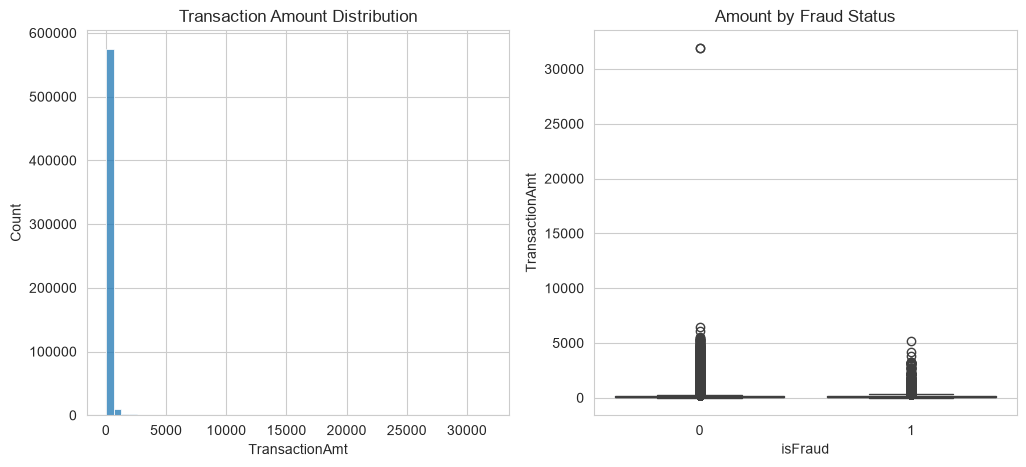

In [8]:
# Transaction amount distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['TransactionAmt'], bins=50)
plt.title('Transaction Amount Distribution')
plt.subplot(1, 2, 2)
sns.boxplot(x='isFraud', y='TransactionAmt', data=df)
plt.title('Amount by Fraud Status')
plt.show()

## 9. Feature Selection Analysis — Identifying Predictive Signals

**What this does:**  
This comprehensive analysis block performs six key feature selection checks:
1. **Null percentage per column** — identifies columns with >90% missing values for potential removal.
2. **Correlation with target** — computes absolute correlation of every numeric feature with `isFraud` to identify the most predictive individual features.
3. **C/D/V block analysis** — drills into the anonymized feature groups (C*, D*, V*) to find the top performers in each group.
4. **Categorical fraud rate breakdown** — computes the fraud rate (mean of `isFraud`) for each category in key categorical columns (`ProductCD`, `card4`, `card6`, `M4`, `M6`, `P_emaildomain`).
5. **TransactionDT range** — checks the time span of the data to determine if a time-based train/test split is appropriate.
6. **Amount by fraud status** — detailed descriptive statistics of `TransactionAmt` split by fraud status.

**Why it's relevant:**  
- **High-null columns** (>90% missing) are typically dropped because imputing them would introduce more noise than signal. This reduces dimensionality and prevents the curse of dimensionality.
- **Correlation with target** is a fast filter method for feature selection. Features with near-zero correlation are unlikely to contribute to a linear model, though they may still be useful for non-linear models (tree-based, neural networks).
- **C/D/V block analysis** is specific to this dataset (IEEE-CIS Fraud Detection). These are anonymized features, and understanding which ones correlate with fraud helps focus feature engineering efforts.
- **Categorical fraud rates** reveal which specific categories (e.g., which email domain, which card type) are most associated with fraud. This can inform one-hot encoding decisions and feature importance interpretation.
- **TransactionDT range** confirms whether the data is time-ordered. If so, a time-based split (train on earlier data, test on later data) is more realistic than random splitting, since fraud patterns evolve over time.
- **Amount by fraud status** provides detailed statistics (mean, std, quartiles) to complement the earlier boxplot visualization.

**How it's done:**  
- Null %: `df.isnull().mean()` gives the fraction of missing values per column. Filtering with `> 0.90` identifies high-null columns.
- Correlation: `df[numeric_cols].corrwith(df['isFraud']).abs()` computes the absolute Pearson correlation between each numeric feature and the target.
- C/D/V filtering: List comprehensions with `.startswith('C')`, `.startswith('D')`, `.startswith('V')` isolate each feature group.
- Categorical breakdown: `df.groupby(col)['isFraud'].agg(['mean', 'count'])` computes fraud rate and sample count per category.
- Time range: `df['TransactionDT'].min()` and `.max()` give the range, divided by 86400 (seconds in a day) to express in days.
- Amount stats: `df.groupby('isFraud')['TransactionAmt'].describe()` provides per-group descriptive statistics.

In [9]:
# ---- 1. Null % per column (decide drop threshold) ----
null_pct = df.isnull().mean().sort_values(ascending=False)
print(null_pct.head(30))

# Drop cols >90% null — not worth imputing
high_null_cols = null_pct[null_pct > 0.90].index.tolist()
print(f"Dropping {len(high_null_cols)} cols >90% null")

# ---- 2. Correlation with target (numeric cols only) ----
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['isFraud', 'TransactionID'])
corr_with_target = df[numeric_cols].corrwith(df['isFraud']).abs().sort_values(ascending=False)
print("\nTop 25 correlated with isFraud:")
print(corr_with_target.head(25))

# ---- 3. C/D/V block top performers specifically ----
c_cols = [c for c in numeric_cols if c.startswith('C')]
d_cols = [c for c in numeric_cols if c.startswith('D')]
v_cols = [c for c in numeric_cols if c.startswith('V')]

print("\nTop C cols:", corr_with_target[c_cols].sort_values(ascending=False).head(5))
print("\nTop D cols:", corr_with_target[d_cols].sort_values(ascending=False).head(5))
print("\nTop 15 V cols:", corr_with_target[v_cols].sort_values(ascending=False).head(15))

# ---- 4. Categorical fraud rate breakdown (not correlation — mean isFraud per category) ----
cat_cols = ['ProductCD', 'card4', 'card6', 'M4', 'M6', 'P_emaildomain']
for col in cat_cols:
    print(f"\nFraud rate by {col}:")
    print(df.groupby(col)['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False))

# ---- 5. TransactionDT range check — confirms time-ordered, needed for time-based split ----
print(f"\nTransactionDT range: {df['TransactionDT'].min()} to {df['TransactionDT'].max()}")
print(f"Range in days: {(df['TransactionDT'].max() - df['TransactionDT'].min()) / 86400:.1f}")

# ---- 6. Amount distribution — fraud vs clean ----
print("\nTransactionAmt by isFraud:")
print(df.groupby('isFraud')['TransactionAmt'].describe())

dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V149     0.861237
V141     0.861237
V146     0.861237
V154     0.861237
V162     0.861237
V142     0.861237
V158     0.861237
V161     0.861237
V157     0.861237
V138     0.861237
V139     0.861237
V148     0.861237
V140     0.861237
V155     0.861237
V156     0.861237
V147     0.861237
V163     0.861237
V143     0.861227
V145     0.861227
V144     0.861227
V165     0.861227
dtype: float64
Dropping 2 cols >90% null

Top 25 correlated with isFraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
V157    0.234866
V155    0.234199
V230    0.23

## 10. Multicollinearity Detection Among V-Features — Correlation Matrix & VIF Analysis

**What this does:**  
This cell performs a deep-dive into multicollinearity among the top-performing V-features (anonymized features identified as most correlated with fraud in the previous step). It uses two complementary methods:

1. **Pairwise correlation matrix** — computes absolute Pearson correlations between all pairs of shortlisted V-features and flags pairs exceeding 0.85 (a common threshold for "highly correlated").
2. **Variance Inflation Factor (VIF)** — a more rigorous multicollinearity check that detects multi-way collinearity that pairwise correlations can miss. VIF > 10 is the standard threshold indicating a feature is highly collinear and a candidate for removal.

**Why it's relevant:**  
- **Multicollinearity** occurs when two or more features are highly correlated with each other. This is problematic because:
  - It inflates the variance of coefficient estimates in linear models, making them unstable and uninterpretable.
  - It can reduce the generalizability of tree-based models by allowing the model to split on redundant features.
  - It wastes model capacity on redundant information.
- **Pairwise correlation** is fast and intuitive but only catches linear relationships between pairs of features. It misses situations where one feature is a linear combination of several others (multi-way collinearity).
- **VIF** addresses this gap. For each feature, VIF measures how much its variance is inflated due to collinearity with all other features. A VIF of 10 means that feature's standard error is √10 ≈ 3.16 times larger than if it were uncorrelated with other features.
- The V-features are anonymized, so we can't use domain knowledge to judge redundancy. Statistical methods like these are the only way to detect and remove redundant features.

**How it's done:**  
- **Correlation matrix**: `df[v_shortlist].corr().abs()` computes the absolute Pearson correlation matrix. A nested loop iterates over the matrix, using a `seen` set to avoid printing duplicate pairs (A↔B and B↔A).
- **VIF**: `variance_inflation_factor` from `statsmodels.stats.outliers_influence` is used. Since VIF requires no missing values, NaNs are temporarily filled with 0 (a placeholder — proper imputation will be done before modeling). The VIF is computed for each feature by regressing it against all other features and calculating `1 / (1 - R²)`. Features with VIF > 10 are flagged as drop candidates.

In [12]:

v_shortlist = ['V257','V246','V244','V242','V201','V200','V189','V188',
               'V258','V45','V158','V156','V149','V228','V44']

# ---- Correlation matrix among shortlisted V-cols ----
corr_matrix = df[v_shortlist].corr().abs()

# Print full matrix
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(corr_matrix.round(2))

# ---- Flag high-correlation pairs (>0.85 = redundant, drop one) ----
print("\nHighly correlated pairs (>0.85):")
seen = set()
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and corr_matrix.loc[row, col] > 0.85:
            pair = tuple(sorted([col, row]))
            if pair not in seen:
                seen.add(pair)
                print(f"{pair[0]} <-> {pair[1]}: {corr_matrix.loc[row, col]:.3f}")

# ---- VIF (stricter multicollinearity check, catches multi-way redundancy corr misses) ----
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = df[v_shortlist].fillna(0)  # VIF needs no NaN — temp fill, real imputation comes later
vif_data = pd.DataFrame()
vif_data["feature"] = v_shortlist
vif_data["VIF"] = [variance_inflation_factor(vif_df.values, i) for i in range(len(v_shortlist))]
print("\nVIF scores (>10 = drop candidate):")
print(vif_data.sort_values('VIF', ascending=False))

      V257  V246  V244  V242  V201  V200  V189  V188  V258   V45  V158  V156  V149  V228   V44
V257  1.00  0.91  0.76  0.75  0.73  0.75  0.52  0.52  0.78  0.74  0.44  0.35  0.33  0.73  0.77
V246  0.91  1.00  0.83  0.83  0.67  0.68  0.57  0.57  0.74  0.67  0.39  0.40  0.37  0.82  0.68
V244  0.76  0.83  1.00  0.97  0.54  0.53  0.66  0.66  0.71  0.45  0.34  0.37  0.37  0.66  0.47
V242  0.75  0.83  0.97  1.00  0.53  0.53  0.65  0.63  0.71  0.46  0.35  0.37  0.37  0.67  0.47
V201  0.73  0.67  0.54  0.53  1.00  0.94  0.80  0.74  0.64  0.67  0.49  0.42  0.40  0.53  0.67
V200  0.75  0.68  0.53  0.53  0.94  1.00  0.71  0.78  0.63  0.66  0.53  0.41  0.40  0.53  0.69
V189  0.52  0.57  0.66  0.65  0.80  0.71  1.00  0.90  0.46  0.38  0.39  0.42  0.42  0.46  0.39
V188  0.52  0.57  0.66  0.63  0.74  0.78  0.90  1.00  0.44  0.37  0.39  0.42  0.44  0.46  0.39
V258  0.78  0.74  0.71  0.71  0.64  0.63  0.46  0.44  1.00  0.67  0.15  0.13  0.12  0.59  0.68
V45   0.74  0.67  0.45  0.46  0.67  0.66  0.38  0.

## 11. Missing EDA Checks — Time Drift, Null Patterns, Engineered Feature Validation, and Numeric Hygiene

This section closes the remaining gaps before locking feature decisions:

1. Fraud rate over time (day + week) for split-drift visibility.
2. Missing-value pattern of locked V-columns by `ProductCD`.
3. Fraud separation checks for engineered `card1_addr1_count` buckets.
4. Fraud rate by hour-of-day.
5. Outlier inspection for locked numeric features.
6. Correlation check among `dist1` and D-columns.

Priority is executed in the same order as modeling risk: split validity and feature interpretation first, then feature usefulness, then hygiene.

C:\Users\jk904\AppData\Local\Temp\ipykernel_34420\2312754844.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day'] = df['TransactionDT'] // 86400
C:\Users\jk904\AppData\Local\Temp\ipykernel_34420\2312754844.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['week'] = df['TransactionDT'] // (86400 * 7)


Daily fraud rate stats:
count    182.000000
mean       0.036048
std        0.009984
min        0.010972
25%        0.028577
50%        0.035639
75%        0.042467
max        0.069942
Name: isFraud, dtype: float64

Weekly fraud rate:
week
0    0.028055
1    0.026148
2    0.025500
3    0.018523
4    0.038226
5    0.038321
6    0.038594
7    0.041199
8    0.045540
9    0.042973
Name: isFraud, dtype: float64


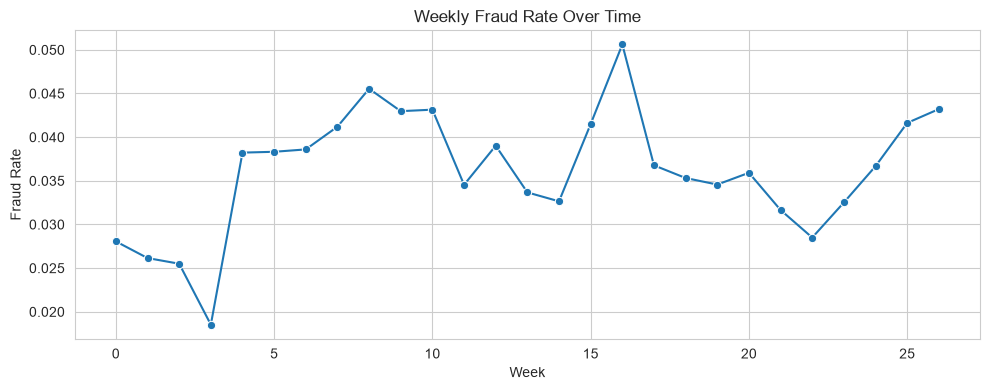


Null rate of locked V-columns by ProductCD:
               V257      V244      V201      V189       V45      V158      V228      V258
ProductCD                                                                                
C          0.240561  0.240561  0.126009  0.126009  0.060757  1.000000  0.240561  0.240561
H          0.003149  0.003149  0.027071  0.027071  0.943435  0.000151  0.003149  0.003149
R          0.074326  0.074326  0.031141  0.031141  0.885169  0.000027  0.074326  0.074326
S          0.090385  0.090385  0.030014  0.030014  1.000000  0.034400  0.090385  0.090385
W          1.000000  1.000000  1.000000  1.000000  0.201633  1.000000  1.000000  1.000000

Fraud rate by card1_addr1_count bucket:
                              mean   count
card1_addr1_count_bucket                  
(-0.001, 11.0]            0.067892  149826
(11.0, 74.0]              0.024508  146439
(74.0, 415.0]             0.025571  146848
(415.0, 5885.0]           0.021346  147427

Top 5 hours by fraud rate

C:\Users\jk904\AppData\Local\Temp\ipykernel_34420\2312754844.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['card1_addr1_count'] = df.groupby(['card1', 'addr1'])['card1'].transform('count')
C:\Users\jk904\AppData\Local\Temp\ipykernel_34420\2312754844.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['card1_addr1_count_bucket'] = pd.qcut(df['card1_addr1_count'].fillna(0), q=4, duplicates='drop')
C:\Users\jk904\AppData\Local\Temp\ipykernel_34420\2312754844.py:38: PerformanceWarning: DataFrame is highly fragmented.  

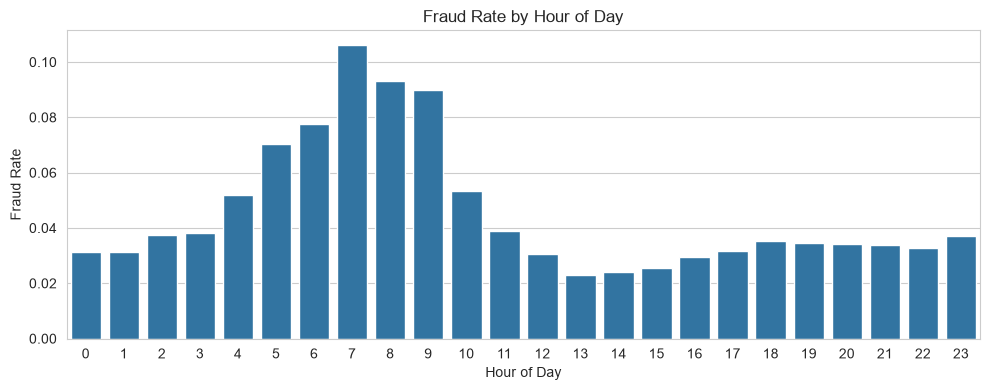


Locked Numeric Columns Percentiles (99%, 99.9%, max):
TransactionAmt  | 99%: 1104.00 | 99.9%: 2769.81 | Max: 31937.39
card1           | 99%: 18238.00 | 99.9%: 18370.00 | Max: 18396.00
card2           | 99%: 583.00 | 99.9%: 599.00 | Max: 600.00
card3           | 99%: 185.00 | 99.9%: 212.00 | Max: 231.00
card5           | 99%: 226.00 | 99.9%: 236.00 | Max: 237.00
addr1           | 99%: 512.00 | 99.9%: 512.00 | Max: 540.00
dist1           | 99%: 2040.00 | 99.9%: 3247.44 | Max: 10286.00
D2              | 99%: 617.00 | 99.9%: 637.00 | Max: 640.00
D8              | 99%: 983.93 | 99.9%: 1219.67 | Max: 1707.79
D10             | 99%: 622.00 | 99.9%: 663.00 | Max: 876.00
D15             | 99%: 635.00 | 99.9%: 701.00 | Max: 879.00

Correlation matrix for dist1 and D-columns:
       dist1     D2     D8    D10    D15
dist1  1.000 -0.043    NaN -0.064 -0.046
D2    -0.043  1.000  0.275  0.526  0.618
D8       NaN  0.275  1.000  0.169  0.227
D10   -0.064  0.526  0.169  1.000  0.712
D15   -0.046  0.618

In [13]:
# ---- 1. Fraud Rate Over Time (Day & Week) ----
df['day'] = df['TransactionDT'] // 86400
df['week'] = df['TransactionDT'] // (86400 * 7)

daily_fraud = df.groupby('day')['isFraud'].mean()
weekly_fraud = df.groupby('week')['isFraud'].mean()

print("Daily fraud rate stats:")
print(daily_fraud.describe())
print("\nWeekly fraud rate:")
print(weekly_fraud.head(10))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.lineplot(x=weekly_fraud.index, y=weekly_fraud.values, marker='o')
plt.title("Weekly Fraud Rate Over Time")
plt.xlabel("Week")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

# ---- 2. Missing-Value Pattern of Locked V-Columns by ProductCD ----
locked_v_cols = ['V257', 'V244', 'V201', 'V189', 'V45', 'V158', 'V228', 'V258']
missing_by_prod = df.groupby('ProductCD')[locked_v_cols].apply(lambda x: x.isnull().mean())
print("\nNull rate of locked V-columns by ProductCD:")
print(missing_by_prod)

# ---- 3. Fraud Separation Checks for Engineered card1_addr1_count ----
df['card1_addr1_count'] = df.groupby(['card1', 'addr1'])['card1'].transform('count')
df['card1_addr1_count_bucket'] = pd.qcut(df['card1_addr1_count'].fillna(0), q=4, duplicates='drop')
count_fraud_rate = df.groupby('card1_addr1_count_bucket')['isFraud'].agg(['mean', 'count'])
print("\nFraud rate by card1_addr1_count bucket:")
print(count_fraud_rate)

# ---- 4. Fraud Rate by Hour-of-Day ----
df['hour_of_day'] = (df['TransactionDT'] // 3600) % 24
hour_fraud_rate = df.groupby('hour_of_day')['isFraud'].agg(['mean', 'count'])
print("\nTop 5 hours by fraud rate:")
print(hour_fraud_rate.sort_values('mean', ascending=False).head(5))

plt.figure(figsize=(10, 4))
sns.barplot(x=hour_fraud_rate.index, y=hour_fraud_rate['mean'])
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

# ---- 5. Outlier Inspection for Locked Numeric Features ----
locked_num_cols = ['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'dist1', 'D2', 'D8', 'D10', 'D15']
print("\nLocked Numeric Columns Percentiles (99%, 99.9%, max):")
for col in locked_num_cols:
    percentiles = df[col].quantile([0.99, 0.999, 1.0])
    print(f"{col:<15} | 99%: {percentiles[0.99]:.2f} | 99.9%: {percentiles[0.999]:.2f} | Max: {percentiles[1.0]:.2f}")

# ---- 6. Correlation Check Among dist1 and D-Columns ----
d_cols_locked = ['D2', 'D8', 'D10', 'D15']
dist_d_cols = ['dist1'] + d_cols_locked
dist_d_corr = df[dist_d_cols].corr()
print("\nCorrelation matrix for dist1 and D-columns:")
print(dist_d_corr.round(3))
